# Correlation Analysis and Linear Regression

## Project Overview

This project investigates the relationship between students' weekly study hours and their Grade Point Average (GPA).

The analysis combines exploratory data analysis (EDA), statistical testing, correlation analysis, and linear regression to determine whether study time is associated with academic performance and whether GPA can be predicted using study hours alone.

The dataset was provided as a CSV file and contains student-level observations related to GPA and weekly study hours.

## Research Questions
This project aims to answer the following questions:

- Does studying more hours lead to higher GPA?
- Is the relationship between study hours and GPA statistically significant?
- Can GPA be predicted using study hours alone?
- How accurately does a linear regression model estimate students' GPA?


## Import Libraries

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind
from scipy.stats import pearsonr

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import seaborn as sns

Importing the libraries required for data manipulation, visualization, statistical analysis, and linear regression modeling.

## Load Dataset
The dataset is loaded into a pandas DataFrame. It contains information about students' GPA and study hours.

In [173]:
df = pd.read_csv("gpa_study_hours.csv")

## Initial Data Inspection
Displaying the first rows of the dataset and checking its structure before further analysis.

In [174]:
df.head()

,rownames,gpa,study_hours
0,1,4.00,10.0
1,2,3.80,25.0
2,3,3.93,45.0
3,4,3.40,10.0
4,5,3.20,4.0


## Dataset Overview
Checking the number of observations, variable types, descriptive statistics, and missing values.

In [175]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rownames     193 non-null    int64  
 1   gpa          193 non-null    float64
 2   study_hours  193 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.7 KB


,rownames,gpa,study_hours
count,193.000000,193.000000,193.000000
mean,97.000000,3.586166,17.476684
std,55.858452,0.285482,11.408980
min,1.000000,2.600000,2.000000
25%,49.000000,3.400000,10.000000
50%,97.000000,3.620000,15.000000
75%,145.000000,3.800000,20.000000
max,193.000000,4.300000,69.000000


In [176]:
shape = df.shape
print("Number of rows:", shape[0])
print("Number of columns:", shape[1])

Number of rows: 193
Number of columns: 3


### Dataset

The dataset contains information about 193 students and includes the following variables:

- GPA – students' Grade Point Average.
- Study Hours – average number of study hours per week.

The dataset is used to examine whether study habits influence academic performance.

#### Cleaning Dataset
This section prepares the dataset for further analysis by removing unnecessary columns and checking for missing values.

In [177]:
print("Removing technical columns...")

df = df.drop(columns=["rownames"], errors="ignore")

print(df.head())

Removing technical columns...
    gpa  study_hours
0  4.00         10.0
1  3.80         25.0
2  3.93         45.0
3  3.40         10.0
4  3.20          4.0


The dataset contains an additional technical column (rownames) that does not provide analytical value. It is removed before further analysis.

In [178]:
print("Checking missing values...")

missing_values = df.isna().sum()

print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values detected.")
else:
    print("\nMissing values were found.")

Checking missing values...
gpa            0
study_hours    0
dtype: int64

No missing values detected.


# Exploratory Data Analysis (EDA)

This section explores the numerical variables contained in the dataset before building the regression model.

The main objectives are:

- understand the data structure,
- inspect variable distributions,
- identify potential outliers,
- evaluate the relationship between study hours and GPA.

## Numerical Variables Summary
This section summarizes the numerical variables included in the dataset. Basic descriptive statistics are calculated for GPA and study hours.

In [179]:
print("=== Numerical Variables Summary ===")

numerical_columns = ["gpa", "study_hours"]

print("Selected numerical variables:")
print(numerical_columns)

print("\nSummary statistics:")

print(
    df[numerical_columns].agg(
        ["count", "mean", "std", "median", "min", "max"]
    )
)

=== Numerical Variables Summary ===
Selected numerical variables:
['gpa', 'study_hours']

Summary statistics:
               gpa  study_hours
count   193.000000   193.000000
mean      3.586166    17.476684
std       0.285482    11.408980
median    3.620000    15.000000
min       2.600000     2.000000
max       4.300000    69.000000


## GPA Distribution

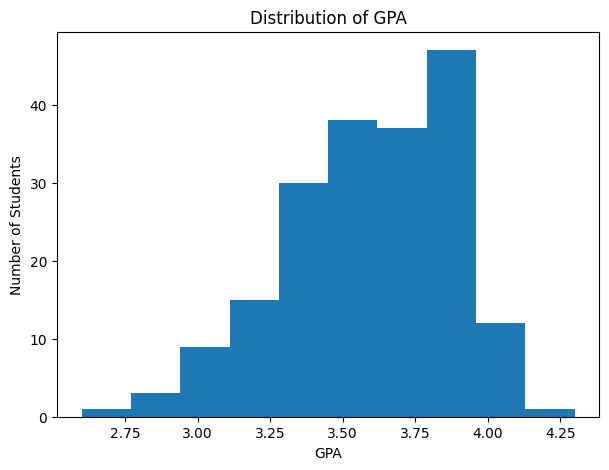

In [180]:
plt.figure(figsize=(7,5))

plt.hist(df["gpa"], bins=10)

plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Number of Students")

plt.show()

### Interpretation

The GPA distribution is concentrated around higher values, suggesting that the analyzed population generally performs well academically. Most students achieved a GPA above **3.3**, whereas values below **3.0** are relatively uncommon. The absence of multiple peaks indicates that the sample represents one dominant group rather than several distinct subgroups.

#### Study Hours Distribution
The histogram presents the distribution of weekly study hours among students.

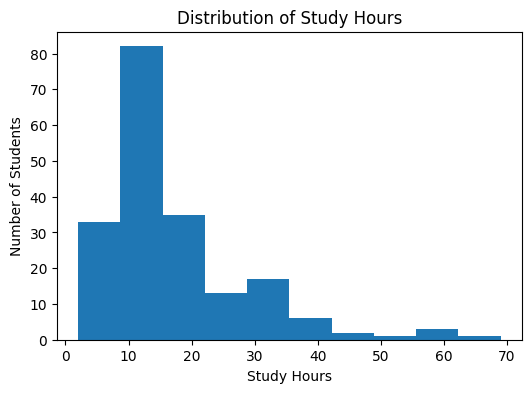

In [181]:
plt.figure(figsize=(6,4))

plt.hist(df["study_hours"], bins=10)

plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Number of Students")

plt.show()

### Interpretation

The majority of students study between **5 and 20 hours per week**, indicating that moderate study time is the most common pattern within the analyzed group. The distribution is positively skewed, with only a small number of students reporting very high study times exceeding **40 hours per week**. This suggests that intensive studying is relatively uncommon among the surveyed students.

## GPA Boxplot
The boxplot is used to identify the median, variability, and potential outliers in GPA values.

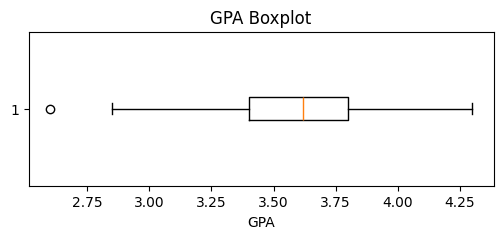

In [182]:
plt.figure(figsize=(6,2))

plt.boxplot(df["gpa"], vert=False)

plt.title("GPA Boxplot")
plt.xlabel("GPA")

plt.show()

### Interpretation

The median GPA is approximately **3.6**, indicating that half of the students achieved a GPA above this value and half below. Most observations are concentrated within a relatively narrow range, suggesting low variability in academic performance. A single lower outlier is visible, representing a student whose GPA is noticeably lower than the rest of the group.

## Study Hours Boxplot
The boxplot illustrates the distribution of study hours and highlights potential outliers.

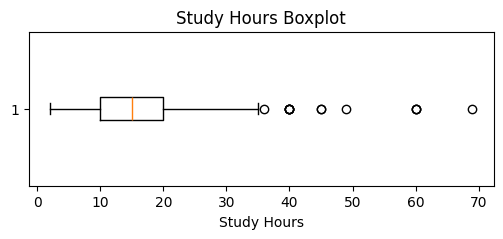

In [183]:
plt.figure(figsize=(6,2))

plt.boxplot(df["study_hours"], vert=False)

plt.title("Study Hours Boxplot")
plt.xlabel("Study Hours")

plt.show()

### Interpretation

The median study time is approximately **15 hours per week**, with most students studying between **10 and 20 hours**. Several observations appear as upper outliers, indicating that a small group of students spends considerably more time studying than the majority. This confirms that the distribution of study hours is positively skewed.

### Initial observation

The scatter plot suggests a positive relationship between study hours and GPA, which will be verified using correlation and linear regression.

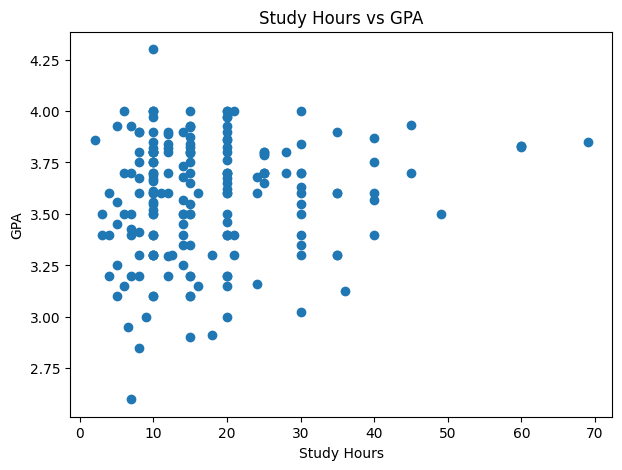

In [184]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["study_hours"],
    df["gpa"]
)

plt.xlabel("Study Hours")
plt.ylabel("GPA")
plt.title("Study Hours vs GPA")

plt.show()

### Interpretation

The scatter plot suggests a weak positive relationship between study hours and GPA. Students who study more tend to achieve slightly higher GPA values, but the points are widely scattered across the chart.

This indicates that study hours may have some relationship with academic performance, but they are unlikely to explain GPA differences on their own. The strength of this relationship will be examined more precisely using correlation analysis and linear regression.

# Correlation Analysis

This section evaluates the strength and direction of the relationship between students' study hours and GPA.

The Pearson correlation coefficient is calculated to measure the linear association between the two numerical variables. A correlation matrix and a heatmap are also presented to provide a visual summary of the relationship.

In [185]:
correlation_matrix = df[["study_hours", "gpa"]].corr()

correlation_matrix

,study_hours,gpa
study_hours,1.000000,0.133014
gpa,0.133014,1.000000


Although the correlation between study hours and GPA is positive, its low magnitude indicates limited explanatory power. Therefore, the next step is to build and evaluate a linear regression model to determine how well study hours predict students' GPA.

In [186]:
from scipy.stats import pearsonr

r, p = pearsonr(
    df["study_hours"],
    df["gpa"]
)

print("Pearson correlation:", round(r,3))
print("p-value:", round(p,4))

Pearson correlation: 0.133
p-value: 0.0652


In [187]:
summary = pd.DataFrame({
    "Metric": [
        "Pearson correlation",
        "Relationship strength",
        "Direction",
        "Statistical significance"
    ],
    "Value": [
        f"{r:.3f}",
        "Very weak",
        "Positive",
        f"p = {p:.4f}"
    ]
})

summary

,Metric,Value
0,Pearson correlation,0.133
1,Relationship strength,Very weak
2,Direction,Positive
3,Statistical significance,p = 0.0652


### Interpretation

The Pearson correlation coefficient (r = 0.133) indicates a very weak positive relationship between study hours and GPA.

Students who spend more time studying tend to achieve slightly higher GPA values; however, the relationship is weak. This suggests that study hours alone are not sufficient to explain differences in academic performance. Other factors are likely to influence students' GPA.
The weak correlation observed in this analysis suggests that study hours alone may not fully explain students' academic performance.

To further investigate this relationship and assess the predictive value of study hours, a simple linear regression model is developed in the next section.

# Comparison of Study Groups

To examine whether study time is associated with academic performance, students are divided into two groups based on the median number of study hours.

The groups are compared using descriptive statistics, boxplots, and Welch's t-test to determine whether students who study more achieve different GPA values than those who study less.

### Creating Study Groups

Students are classified into two study groups based on the median number of study hours.

- Low Study – below the median.
- High Study – equal to or above the median.

In [188]:
study_hours_median = df["study_hours"].median()

df["study_group"] = np.where(
    df["study_hours"] >= study_hours_median,
    "High Study",
    "Low Study"
)

## Preview of Study Groups

The first observations are displayed to verify that the new categorical variable (study_group) has been created correctly.

In [189]:
df[["study_hours", "gpa", "study_group"]].head()

,study_hours,gpa,study_group
0,10.0,4.00,Low Study
1,25.0,3.80,High Study
2,45.0,3.93,High Study
3,10.0,3.40,Low Study
4,4.0,3.20,Low Study


## Group Size

The number of students in each study group is calculated to verify that both groups contain a comparable number of observations before performing statistical analysis.

In [190]:
df["study_group"].value_counts()

,count
study_group,
High Study,100
Low Study,93


## GPA Summary Statistics

Descriptive statistics are calculated separately for each study group. The comparison includes the number of students, mean GPA, median GPA, standard deviation, minimum, and maximum values.

In [191]:
gpa_stats = (
    df.groupby("study_group")["gpa"]
      .agg(["count", "mean", "median", "std", "min", "max"])
)

gpa_stats

,count,mean,median,std,min,max
study_group,,,,,,
High Study,100,3.606270,3.6775,0.276416,2.9,4.0
Low Study,93,3.564548,3.6000,0.294882,2.6,4.3


The average GPA is slightly higher for students in the High Study group (3.61) than for those in the Low Study group (3.57). The variability of GPA is similar in both groups, suggesting comparable distributions before formal hypothesis testing.

## GPA Distribution by Study Group

Boxplots provide a visual comparison of GPA distributions between students who study less and those who study more. The visualization highlights differences in central tendency, variability, and potential outliers.

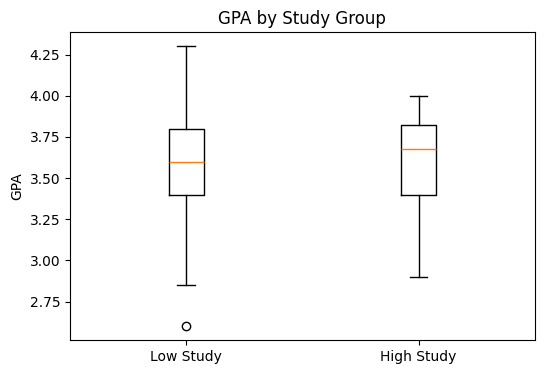

In [192]:
plt.figure(figsize=(6,4))

plt.boxplot(
    [
        df.loc[df["study_group"]=="Low Study","gpa"],
        df.loc[df["study_group"]=="High Study","gpa"]
    ],
    tick_labels=["Low Study","High Study"]
)

plt.ylabel("GPA")
plt.title("GPA by Study Group")

plt.show()

## Welch's t-test

Welch's t-test is performed to evaluate whether the difference in mean GPA between the two study groups is statistically significant.

In [193]:
gpa_low = df.loc[df["study_group"]=="Low Study","gpa"]
gpa_high = df.loc[df["study_group"]=="High Study","gpa"]

t_stat, p_value = ttest_ind(
    gpa_low,
    gpa_high,
    equal_var=False
)

print("t statistic:", round(t_stat,3))
print("p-value:", round(p_value,4))

t statistic: -1.012
p-value: 0.3128


### Interpretation

Students in the High Study group achieved a slightly higher average GPA (3.61) than students in the Low Study group (3.57).

However, Welch's t-test returned a p-value of 0.313, which is greater than the significance level of 0.05. Therefore, the observed difference is not statistically significant.

This suggests that study hours alone do not explain differences in students' GPA within this dataset.

# Linear Regression

A simple linear regression model is used to evaluate whether students' GPA can be predicted based on the number of study hours.

The model uses:

- **Study Hours** as the predictor variable,
- **GPA** as the target variable.

The goal is not only to build the model, but also to evaluate whether study hours alone provide enough information to make accurate GPA predictions.

In [194]:
X = df[["study_hours"]]
y = df["gpa"]

## Train-Test Split

The dataset is divided into a training set and a testing set.

The training set is used to fit the regression model, while the testing set is used to evaluate how well the model performs on unseen data.

In [195]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 154
Testing observations: 39


## Model Training

A linear regression model is trained using the training dataset.

In [196]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## Regression Equation

The regression coefficient shows how much GPA is expected to change when study time increases by one hour.

The intercept represents the predicted GPA when study hours are equal to zero.

In [197]:
coefficient = model.coef_[0]
intercept = model.intercept_

print("Regression coefficient:", round(coefficient, 4))
print("Intercept:", round(intercept, 4))

Regression coefficient: 0.0034
Intercept: 3.5213


### Interpretation

The regression coefficient is positive, which means that the model estimates a slight increase in GPA as study hours increase.

However, the coefficient is very small. This suggests that each additional hour of study is associated with only a minimal increase in predicted GPA.

## Regression Line Visualization

The regression line is plotted together with the observed data points to visually assess the relationship between study hours and GPA.

In [198]:
x_range = np.linspace(
    df["study_hours"].min(),
    df["study_hours"].max(),
    100
)

y_line = model.predict(
    pd.DataFrame({"study_hours": x_range})
)

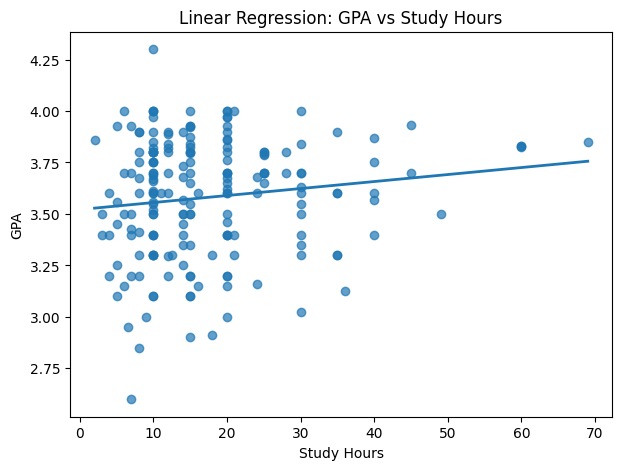

In [199]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["study_hours"],
    df["gpa"],
    alpha=0.7
)

plt.plot(
    x_range,
    y_line,
    linewidth=2
)

plt.title("Linear Regression: GPA vs Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("GPA")

plt.show()

### Interpretation

The regression line has a slight upward slope, indicating a weak positive relationship between study hours and GPA.

However, the observations are widely scattered around the line. This suggests that study hours alone do not explain most of the variation in students' GPA.

## Predictions

The trained model is used to predict GPA values for selected study-hour scenarios.

In [200]:
new_data = pd.DataFrame({
    "study_hours": [2, 8, 12, 18]
})

new_data["Predicted GPA"] = model.predict(new_data)

new_data

,study_hours,Predicted GPA
0,2,3.528142
1,8,3.548543
2,12,3.562144
3,18,3.582545


## Model Evaluation

The model is evaluated using standard regression metrics:

- **R²** — explains how much variation in GPA is captured by the model,
- **MAE** — average absolute prediction error,
- **MSE** — average squared prediction error,
- **RMSE** — prediction error expressed in the original GPA scale.

In [201]:
y_pred = model.predict(X_test)

In [206]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

model_metrics = pd.DataFrame({
    "Metric": ["R²", "MAE", "MSE", "RMSE"],
    "Value": [
        round(r2, 4),
        round(mae, 4),
        round(mse, 4),
        round(rmse, 4)
    ]
})

model_metrics

,Metric,Value
0,R²,0.0027
1,MAE,0.2096
2,MSE,0.0659
3,RMSE,0.2568


### Interpretation

The model has very limited predictive power. The R² value is close to zero, which means that study hours explain only a very small proportion of the variation in students' GPA.

The average prediction error is approximately 0.21 GPA points. Although this error may appear relatively small, it should be interpreted carefully because GPA values have a limited range.

Overall, the results indicate that study hours alone are not sufficient to accurately predict academic performance. Other factors, such as prior knowledge, learning strategies, attendance, motivation, sleep quality, or exam difficulty, are likely to play an important role.

## Actual vs Predicted Values

The table below compares actual GPA values from the test set with GPA values predicted by the regression model.

In [207]:
results = pd.DataFrame({
    "Study Hours": X_test["study_hours"],
    "Actual GPA": y_test,
    "Predicted GPA": y_pred
})

results = results.sort_values("Study Hours")

results.head(10)

,Study Hours,Actual GPA,Predicted GPA
60,2.0,3.86,3.528142
67,3.0,3.50,3.531542
78,6.0,3.50,3.541743
16,6.0,3.15,3.541743
76,7.0,3.20,3.545143
30,7.0,3.40,3.545143
18,8.0,3.80,3.548543
152,8.0,2.85,3.548543
9,10.0,3.75,3.555343
68,10.0,3.80,3.555343


## Actual vs Predicted Plot

The plot compares actual GPA values with model predictions. In a well-performing regression model, points should be located close to the diagonal reference line.

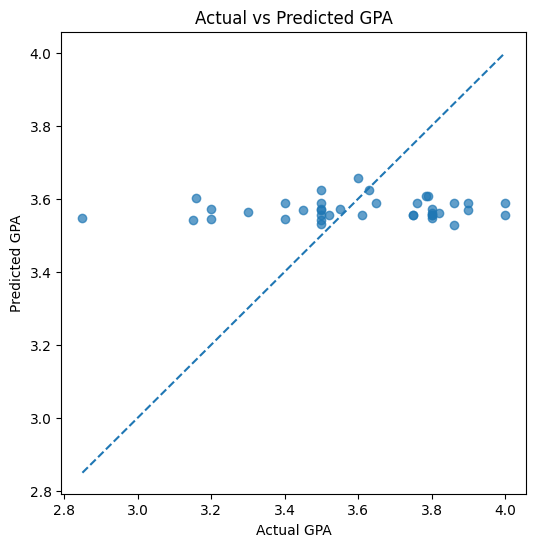

In [209]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted GPA")
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")

plt.show()

### Interpretation

The predicted GPA values are concentrated within a narrow range, while the actual GPA values show greater variation.

This indicates that the model tends to make conservative predictions close to the average GPA and does not capture individual differences very well.

## Residual Analysis

Residuals represent the difference between actual and predicted GPA values.

A residual plot helps assess whether prediction errors follow any visible pattern.

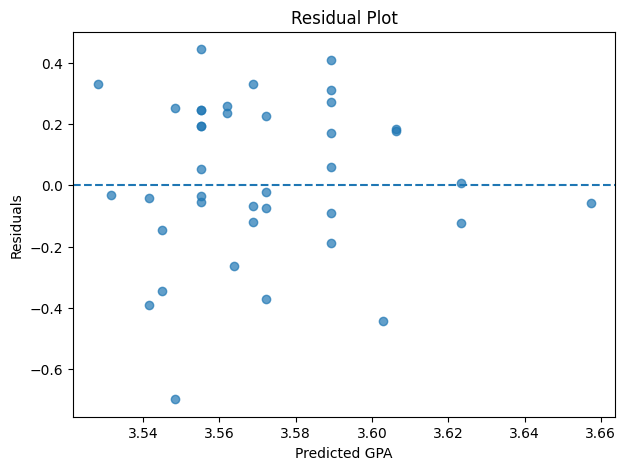

In [205]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted GPA")
plt.ylabel("Residuals")

plt.show()

### Interpretation

The residuals are spread around zero, which means that the model makes both overestimations and underestimations.

However, the spread of residuals confirms that study hours alone do not provide enough information to make highly accurate GPA predictions.

## Key Findings

The relationship between study hours and GPA is positive but very weak.

The linear regression model explains only a very small part of GPA variability, which confirms that study hours alone are not a strong predictor of academic performance.

The model may be useful for demonstrating the regression workflow, but it should not be treated as a reliable GPA prediction tool without additional explanatory variables.

# Conclusions

This project examined the relationship between students' study hours and GPA using exploratory data analysis, statistical testing, correlation analysis, and linear regression.

The analysis showed that students who study more tend to achieve slightly higher GPA values, but the relationship is weak. The comparison of study groups also did not provide strong evidence that study time alone leads to significantly different GPA outcomes.

The regression model achieved very low explanatory power, indicating that study hours explain only a minimal part of GPA variation. This suggests that academic performance is influenced by multiple factors, not only the amount of time spent studying.

Future improvements could include additional variables such as attendance, prior grades, motivation, learning strategies, sleep quality, or course difficulty. Including more predictors would likely improve the model's ability to explain and predict students' academic performance.